# Olist E-commerce: Dataset Overview

This notebook documents the exploratory analysis supporting the interactive dashboard. It uses the prepared order-item dataset created in `IT5006-Olist_Getting_Started.ipynb` and the original Olist source tables.

The prepared dataset contains one row per order item. An item is identified by the combination of `order_id` and `order_item_id`.

## 1. Prepared Analysis Dataset

In [298]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import StrMethodFormatter

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

DATA_DIR = Path("data")
CONSOLIDATED_PATH = DATA_DIR / "smartcommerce_consolidated.csv"

if not CONSOLIDATED_PATH.exists():
    raise FileNotFoundError(
        f"Prepared dataset not found: {CONSOLIDATED_PATH.resolve()}"
    )

line_items = pd.read_csv(
    CONSOLIDATED_PATH,
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)

print(f"Loaded: {CONSOLIDATED_PATH}")
print(f"Shape: {line_items.shape[0]:,} rows × {line_items.shape[1]} columns")
line_items.head()

Loaded: data/smartcommerce_consolidated.csv
Shape: 112,650 rows × 25 columns


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,product_weight_g,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_state,customer_city,seller_state,order_date,year_month,year,month,day_of_week,delivery_days,is_on_time,item_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,650.00,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,RJ,campos dos goytacazes,SP,2017-09-13,2017-09,2017,9,Wednesday,7.00,True,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,30000.00,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,SP,santa fe do sul,SP,2017-04-26,2017-04,2017,4,Wednesday,16.00,True,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,3050.00,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,MG,para de minas,MG,2018-01-14,2018-01,2018,1,Sunday,7.00,True,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,200.00,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,SP,atibaia,SP,2018-08-08,2018-08,2018,8,Wednesday,6.00,True,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,3750.00,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,SP,varzea paulista,PR,2017-02-04,2017-02,2017,2,Saturday,25.00,True,218.04


## 2. Data Sources and Structure

Olist is provided as nine related source tables. The prepared analysis dataset retains the order-item grain, while the source tables remain available for analyses requiring payment, review, or geographic information.

In [299]:
# Load the raw tables needed to validate the source data and joins.
SOURCE_FILES = {
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

missing_files = [filename for filename in SOURCE_FILES.values() if not (DATA_DIR / filename).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing source files: {missing_files}")

raw = {name: pd.read_csv(DATA_DIR / filename) for name, filename in SOURCE_FILES.items()}
raw["orders"] = pd.read_csv(
    DATA_DIR / SOURCE_FILES["orders"],
    parse_dates=[
        "order_purchase_timestamp", "order_approved_at",
        "order_delivered_carrier_date", "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)


In [300]:
# Inventory of the source tables used in this notebook.
TABLE_ROLES = {
    "orders": "Order status and lifecycle timestamps",
    "order_items": "Order-item transactions, prices, freight, and seller",
    "customers": "Customer identity and location",
    "products": "Product category and physical attributes",
    "sellers": "Seller location",
    "payments": "Payment method, instalments, and value",
    "reviews": "Customer review scores and comments",
    "geolocation": "ZIP-prefix latitude and longitude observations",
    "category_translation": "Portuguese-to-English category mapping",
}

source_inventory = pd.DataFrame([
    {
        "Table": name,
        "Rows": len(raw[name]),
        "Columns": raw[name].shape[1],
        "Role": TABLE_ROLES[name],
    }
    for name in SOURCE_FILES
])
source_inventory

,Table,Rows,Columns,Role
0,orders,99441,8,Order status and lifecycle timestamps
1,order_items,112650,7,"Order-item transactions, prices, freight, and ..."
2,customers,99441,5,Customer identity and location
3,products,32951,9,Product category and physical attributes
4,sellers,3095,4,Seller location
5,payments,103886,5,"Payment method, instalments, and value"
6,reviews,99224,7,Customer review scores and comments
7,geolocation,1000163,5,ZIP-prefix latitude and longitude observations
8,category_translation,71,2,Portuguese-to-English category mapping


## 3. Data Quality Assessment

The source tables are assessed for completeness, duplicate keys, referential integrity, valid values, and logical timestamp order. These checks identify issues that could affect preparation or interpretation of the consolidated dataset.

In [301]:
# Table-level completeness profile.
quality_profile = pd.DataFrame([
    {
        "Table": name,
        "Rows": len(table),
        "Columns": table.shape[1],
        "Missing cells": int(table.isna().sum().sum()),
        "Missing cells (%)": table.isna().mean().mean() * 100,
    }
    for name, table in raw.items()
])
quality_profile

,Table,Rows,Columns,Missing cells,Missing cells (%)
0,orders,99441,8,4908,0.62
1,order_items,112650,7,0,0.00
2,customers,99441,5,0,0.00
3,products,32951,9,2448,0.83
4,sellers,3095,4,0,0.00
5,payments,103886,5,0,0.00
6,reviews,99224,7,145903,21.01
7,geolocation,1000163,5,0,0.00
8,category_translation,71,2,0,0.00


In [302]:
# Columns with missing values, ordered by missingness within each table.
missingness = pd.concat(
    [
        table.isna().mean().mul(100).rename("Missing (%)").reset_index().assign(Table=name)
        for name, table in raw.items()
    ],
    ignore_index=True,
).rename(columns={"index": "Column"})

missingness.loc[missingness["Missing (%)"].gt(0)].sort_values(
    ["Table", "Missing (%)"], ascending=[True, False]
).reset_index(drop=True)

,Column,Missing (%),Table
0,order_delivered_customer_date,2.98,orders
1,order_delivered_carrier_date,1.79,orders
2,order_approved_at,0.16,orders
3,product_category_name,1.85,products
4,product_name_lenght,1.85,products
5,product_description_lenght,1.85,products
6,product_photos_qty,1.85,products
7,product_weight_g,0.01,products
8,product_length_cm,0.01,products
9,product_height_cm,0.01,products


In [303]:
# Key uniqueness and foreign-key coverage checks.
orders = raw["orders"]
order_items = raw["order_items"]
customers = raw["customers"]
products = raw["products"]
sellers = raw["sellers"]

integrity_checks = pd.DataFrame([
    {"Check": "Duplicate order IDs", "Affected rows": orders.duplicated("order_id").sum()},
    {"Check": "Duplicate customer IDs", "Affected rows": customers.duplicated("customer_id").sum()},
    {"Check": "Duplicate product IDs", "Affected rows": products.duplicated("product_id").sum()},
    {"Check": "Duplicate seller IDs", "Affected rows": sellers.duplicated("seller_id").sum()},
    {"Check": "Duplicate order-item keys", "Affected rows": order_items.duplicated(["order_id", "order_item_id"]).sum()},
    {"Check": "Orders without a customer", "Affected rows": (~orders["customer_id"].isin(customers["customer_id"])).sum()},
    {"Check": "Items without an order", "Affected rows": (~order_items["order_id"].isin(orders["order_id"])).sum()},
    {"Check": "Items without a product", "Affected rows": (~order_items["product_id"].isin(products["product_id"])).sum()},
    {"Check": "Items without a seller", "Affected rows": (~order_items["seller_id"].isin(sellers["seller_id"])).sum()},
    {"Check": "Payments without an order", "Affected rows": (~raw["payments"]["order_id"].isin(orders["order_id"])).sum()},
    {"Check": "Reviews without an order", "Affected rows": (~raw["reviews"]["order_id"].isin(orders["order_id"])).sum()},
    {"Check": "Duplicate payment keys", "Affected rows": raw["payments"].duplicated(["order_id", "payment_sequential"]).sum()},
    {"Check": "Duplicate review IDs", "Affected rows": raw["reviews"].duplicated("review_id").sum()},
    {"Check": "Products without an English category translation", "Affected rows": (products["product_category_name"].notna() & ~products["product_category_name"].isin(raw["category_translation"]["product_category_name"])).sum()},
])
integrity_checks.assign(Status=lambda frame: frame["Affected rows"].eq(0).map({True: "No issues identified", False: "Records identified"}))

,Check,Affected rows,Status
0,Duplicate order IDs,0,No issues identified
1,Duplicate customer IDs,0,No issues identified
2,Duplicate product IDs,0,No issues identified
3,Duplicate seller IDs,0,No issues identified
4,Duplicate order-item keys,0,No issues identified
5,Orders without a customer,0,No issues identified
6,Items without an order,0,No issues identified
7,Items without a product,0,No issues identified
8,Items without a seller,0,No issues identified
9,Payments without an order,0,No issues identified


In [304]:
# Domain and chronology checks. These identify records that should be examined before use.
valid_statuses = {
    "created", "approved", "invoiced", "processing",
    "shipped", "delivered", "canceled", "unavailable",
}

validity_checks = pd.DataFrame([
    {"Check": "Unknown order statuses", "Affected rows": (~orders["order_status"].isin(valid_statuses)).sum()},
    {"Check": "Non-positive item prices", "Affected rows": order_items["price"].le(0).sum()},
    {"Check": "Negative freight values", "Affected rows": order_items["freight_value"].lt(0).sum()},
    {"Check": "Non-positive payment values", "Affected rows": raw["payments"]["payment_value"].le(0).sum()},
    {"Check": "Payment instalments below 1", "Affected rows": raw["payments"]["payment_installments"].lt(1).sum()},
    {"Check": "Unrecognised payment types", "Affected rows": (~raw["payments"]["payment_type"].isin({"credit_card", "boleto", "voucher", "debit_card"})).sum()},
    {"Check": "Review scores outside 1-5", "Affected rows": (~raw["reviews"]["review_score"].between(1, 5)).sum()},
    {"Check": "Approval before purchase", "Affected rows": (orders["order_approved_at"] < orders["order_purchase_timestamp"]).sum()},
    {"Check": "Carrier handoff before approval", "Affected rows": (orders["order_delivered_carrier_date"] < orders["order_approved_at"]).sum()},
    {"Check": "Customer delivery before purchase", "Affected rows": (orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]).sum()},
    {"Check": "Estimated delivery before purchase", "Affected rows": (orders["order_estimated_delivery_date"] < orders["order_purchase_timestamp"]).sum()},
])
validity_checks.assign(Status=lambda frame: frame["Affected rows"].eq(0).map({True: "No issues identified", False: "Records identified"}))

,Check,Affected rows,Status
0,Unknown order statuses,0,No issues identified
1,Non-positive item prices,0,No issues identified
2,Negative freight values,0,No issues identified
3,Non-positive payment values,9,Records identified
4,Payment instalments below 1,2,Records identified
5,Unrecognised payment types,3,Records identified
6,Review scores outside 1-5,0,No issues identified
7,Approval before purchase,0,No issues identified
8,Carrier handoff before approval,1359,Records identified
9,Customer delivery before purchase,0,No issues identified


In [305]:
# Cardinality checks describe valid one-to-many relationships that affect later joins.
cardinality_summary = pd.DataFrame({
    "Measure": [
        "Orders with multiple review records",
        "Geolocation rows",
        "Unique geolocation ZIP prefixes",
        "Repeated geolocation ZIP-prefix rows",
    ],
    "Count": [
        raw["reviews"].groupby("order_id").size().gt(1).sum(),
        len(raw["geolocation"]),
        raw["geolocation"]["geolocation_zip_code_prefix"].nunique(),
        raw["geolocation"].duplicated("geolocation_zip_code_prefix").sum(),
    ],
})
cardinality_summary

,Measure,Count
0,Orders with multiple review records,547
1,Geolocation rows,1000163
2,Unique geolocation ZIP prefixes,19015
3,Repeated geolocation ZIP-prefix rows,981148


## 4. Marketplace Overview

The metrics below use the prepared order-item dataset. Product sales and average order value exclude freight.

In [306]:
order_count = line_items["order_id"].nunique()
items_sold = len(line_items)
product_sales = line_items["price"].sum()
freight_revenue = line_items["freight_value"].sum()
seller_count = line_items["seller_id"].nunique()
order_values = line_items.groupby("order_id")["price"].sum()
order_customers = line_items[["order_id", "customer_id"]].drop_duplicates().merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left",
    validate="one_to_one",
)
unique_customers = order_customers["customer_unique_id"].nunique()

overview_kpis = pd.DataFrame({
    "Metric": [
        "Product sales (R$)",
        "Freight revenue (R$)",
        "Checkout value incl. freight (R$)",
        "Freight share of checkout value (%)",
        "Total orders",
        "Items sold",
        "Unique customers",
        "Number of sellers",
        "Average order value (R$)",
        "Median order value (R$)",
        "Items per order",
    ],
    "Value": [
        product_sales,
        freight_revenue,
        product_sales + freight_revenue,
        freight_revenue / (product_sales + freight_revenue) * 100,
        order_count,
        items_sold,
        unique_customers,
        seller_count,
        product_sales / order_count,
        order_values.median(),
        items_sold / order_count,
    ],
})

overview_kpis

,Metric,Value
0,Product sales (R$),13591643.70
1,Freight revenue (R$),2251909.54
2,Checkout value incl. freight (R$),15843553.24
3,Freight share of checkout value (%),14.21
4,Total orders,98666.00
5,Items sold,112650.00
6,Unique customers,95420.00
7,Number of sellers,3095.00
8,Average order value (R$),137.75
9,Median order value (R$),86.90


### 4.1 Order Status Mix

Status counts use the same consolidated order population as the overview KPIs. A table is used because delivered orders dominate the distribution and a linear bar chart would make the remaining statuses difficult to compare, while a logarithmic axis would make their relative magnitude less intuitive.

In [307]:
order_status_summary = (
    line_items[["order_id", "order_status"]]
    .drop_duplicates("order_id")
    .groupby("order_status", as_index=False)
    .agg(total_orders=("order_id", "size"))
    .sort_values("total_orders", ascending=False)
)
order_status_summary["order_share_pct"] = order_status_summary["total_orders"] / order_count * 100
order_status_summary

,order_status,total_orders,order_share_pct
2,delivered,96478,97.78
5,shipped,1106,1.12
1,canceled,461,0.47
3,invoiced,312,0.32
4,processing,301,0.31
6,unavailable,6,0.01
0,approved,2,0.00


## 5. Temporal Patterns

Monthly trends are calculated from order purchase timestamps. January 2017 to August 2018 is used for the monthly charts to exclude the launch period and incomplete boundary months. The retained date window is stated in each monthly figure title.

In [308]:
TREND_START = pd.Timestamp("2017-01-01")
TREND_END = pd.Timestamp("2018-09-01")

monthly_overview = (
    line_items.loc[
        line_items["order_purchase_timestamp"].ge(TREND_START)
        & line_items["order_purchase_timestamp"].lt(TREND_END)
    ]
    .assign(month=lambda frame: frame["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        product_sales=("price", "sum"),
        items_sold=("order_item_id", "size"),
    )
)
monthly_overview["average_order_value"] = (
    monthly_overview["product_sales"] / monthly_overview["total_orders"]
)
monthly_overview["items_per_order"] = (
    monthly_overview["items_sold"] / monthly_overview["total_orders"]
)

monthly_overview.head()

,month,total_orders,product_sales,items_sold,average_order_value,items_per_order
0,2017-01-01,789,120312.87,955,152.49,1.21
1,2017-02-01,1733,247303.02,1951,142.70,1.13
2,2017-03-01,2641,374344.30,3000,141.74,1.14
3,2017-04-01,2391,359927.23,2684,150.53,1.12
4,2017-05-01,3660,506071.14,4136,138.27,1.13


### 5.1 Order and Sales Trends

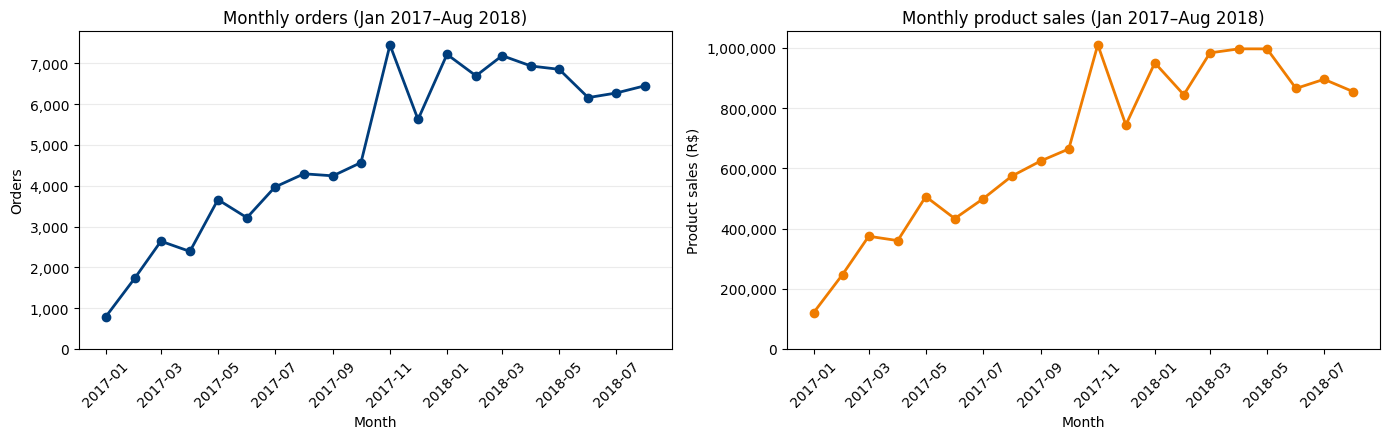

In [309]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(
    monthly_overview["month"], monthly_overview["total_orders"],
    marker="o", linewidth=2, color="#003D7C",
)
axes[0].set_title("Monthly orders (Jan 2017–Aug 2018)")
axes[0].set_ylabel("Orders")
axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

axes[1].plot(
    monthly_overview["month"], monthly_overview["product_sales"],
    marker="o", linewidth=2, color="#EF7C00",
)
axes[1].set_title("Monthly product sales (Jan 2017–Aug 2018)")
axes[1].set_ylabel("Product sales (R$)")
axes[1].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

for axis in axes:
    axis.set_xlabel("Month")
    axis.set_ylim(bottom=0)
    axis.grid(axis="y", alpha=0.25)
    axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 5.2 Commercial Performance Over Time

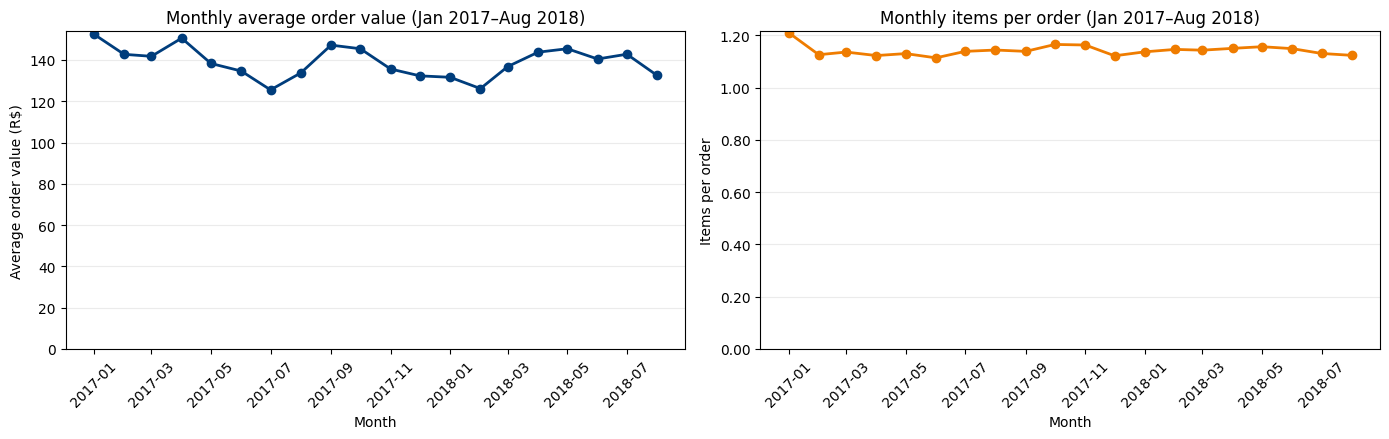

In [310]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(
    monthly_overview["month"], monthly_overview["average_order_value"],
    marker="o", linewidth=2, color="#003D7C",
)
axes[0].set_title("Monthly average order value (Jan 2017–Aug 2018)")
axes[0].set_ylabel("Average order value (R$)")
axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

axes[1].plot(
    monthly_overview["month"], monthly_overview["items_per_order"],
    marker="o", linewidth=2, color="#EF7C00",
)
axes[1].set_title("Monthly items per order (Jan 2017–Aug 2018)")
axes[1].set_ylabel("Items per order")
axes[1].yaxis.set_major_formatter(StrMethodFormatter("{x:,.2f}"))

for axis in axes:
    axis.set_xlabel("Month")
    axis.set_ylim(bottom=0)
    axis.grid(axis="y", alpha=0.25)
    axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 5.3 Purchase Timing Patterns

Unlike the monthly trend charts, the weekday and hour distributions use all consolidated orders because they are not boundary-month time series. Each order is counted once.

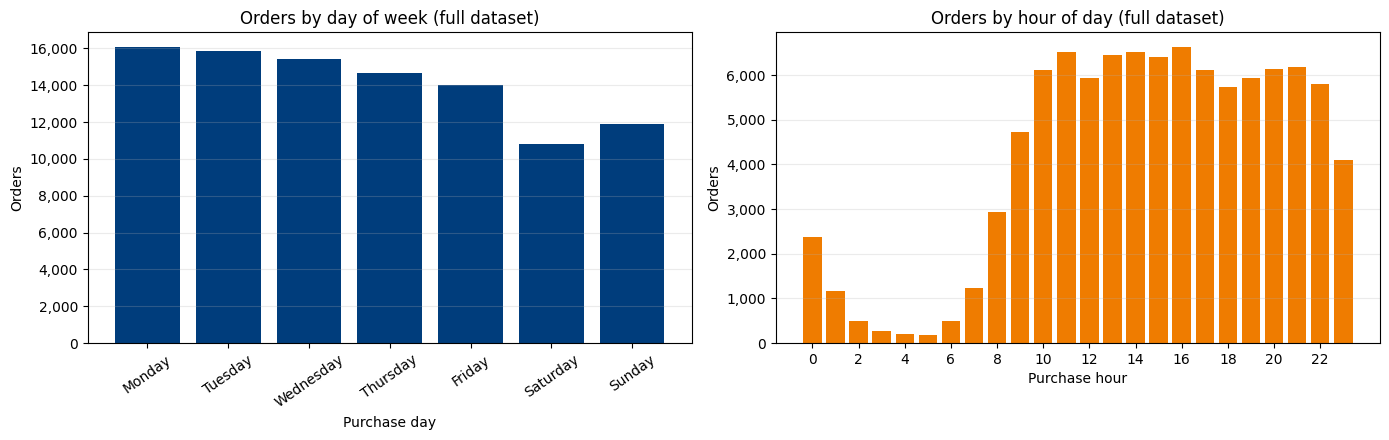

In [311]:
# Use one record per order so orders containing multiple items are counted once.
purchase_timing = line_items[["order_id", "order_purchase_timestamp"]].drop_duplicates("order_id")
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
orders_by_day = (
    purchase_timing["order_purchase_timestamp"].dt.day_name()
    .value_counts()
    .reindex(day_order)
)
orders_by_hour = (
    purchase_timing["order_purchase_timestamp"].dt.hour
    .value_counts()
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(orders_by_day.index, orders_by_day.values, color="#003D7C")
axes[0].set_title("Orders by day of week (full dataset)")
axes[0].set_xlabel("Purchase day")
axes[0].set_ylabel("Orders")
axes[0].tick_params(axis="x", rotation=35)

axes[1].bar(orders_by_hour.index, orders_by_hour.values, color="#EF7C00")
axes[1].set_title("Orders by hour of day (full dataset)")
axes[1].set_xlabel("Purchase hour")
axes[1].set_ylabel("Orders")
axes[1].set_xticks(range(0, 24, 2))

for axis in axes:
    axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    axis.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 6. Customer, Seller and Product Distributions

### 6.1 Customer Geographic Distribution

In [312]:
# Count each order once, regardless of the number of items it contains.
customer_order_locations = line_items[["order_id", "customer_state"]].drop_duplicates("order_id")
customer_state_summary = (
    customer_order_locations.groupby("customer_state", as_index=False)
    .agg(total_orders=("order_id", "nunique"))
    .sort_values("total_orders", ascending=False)
)
customer_state_summary["order_share_pct"] = customer_state_summary["total_orders"] / order_count * 100
customer_state_summary.head(10)

,customer_state,total_orders,order_share_pct
25,SP,41375,41.93
18,RJ,12762,12.93
10,MG,11544,11.70
22,RS,5432,5.51
17,PR,4998,5.07
23,SC,3612,3.66
4,BA,3358,3.40
6,DF,2125,2.15
7,ES,2025,2.05
8,GO,2007,2.03


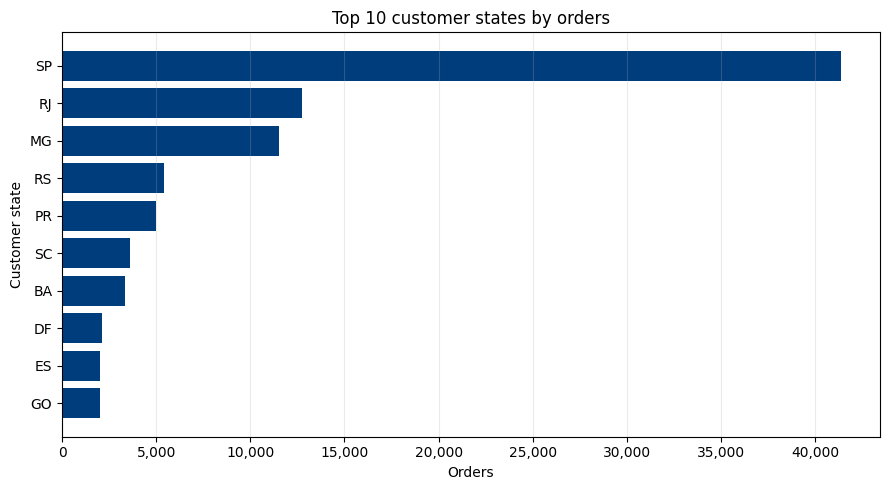

In [313]:
top_customer_states = customer_state_summary.head(10).sort_values("total_orders")
fig, axis = plt.subplots(figsize=(9, 5))
axis.barh(top_customer_states["customer_state"], top_customer_states["total_orders"], color="#003D7C")
axis.set_title("Top 10 customer states by orders")
axis.set_xlabel("Orders")
axis.set_ylabel("Customer state")
axis.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axis.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### 6.2 Product Category Distribution

In [314]:
category_items = line_items.assign(
    product_category_name_english=line_items["product_category_name_english"].fillna("Unknown")
)
product_category_summary = (
    category_items.groupby("product_category_name_english", as_index=False)
    .agg(
        items_sold=("order_item_id", "size"),
        total_orders=("order_id", "nunique"),
        product_sales=("price", "sum"),
    )
)
product_category_summary["item_share_pct"] = product_category_summary["items_sold"] / items_sold * 100
product_category_summary.sort_values("items_sold", ascending=False).head(10)

,product_category_name_english,items_sold,total_orders,product_sales,item_share_pct
8,bed_bath_table,11115,9417,1036988.68,9.87
44,health_beauty,9670,8836,1258681.34,8.58
66,sports_leisure,8641,7720,988048.97,7.67
40,furniture_decor,8334,6449,729762.49,7.40
16,computers_accessories,7827,6689,911954.32,6.95
50,housewares,6964,5884,632248.66,6.18
71,watches_gifts,5991,5624,1205005.68,5.32
69,telephony,4545,4199,323667.53,4.03
43,garden_tools,4347,3518,485256.46,3.86
6,auto,4235,3897,592720.11,3.76


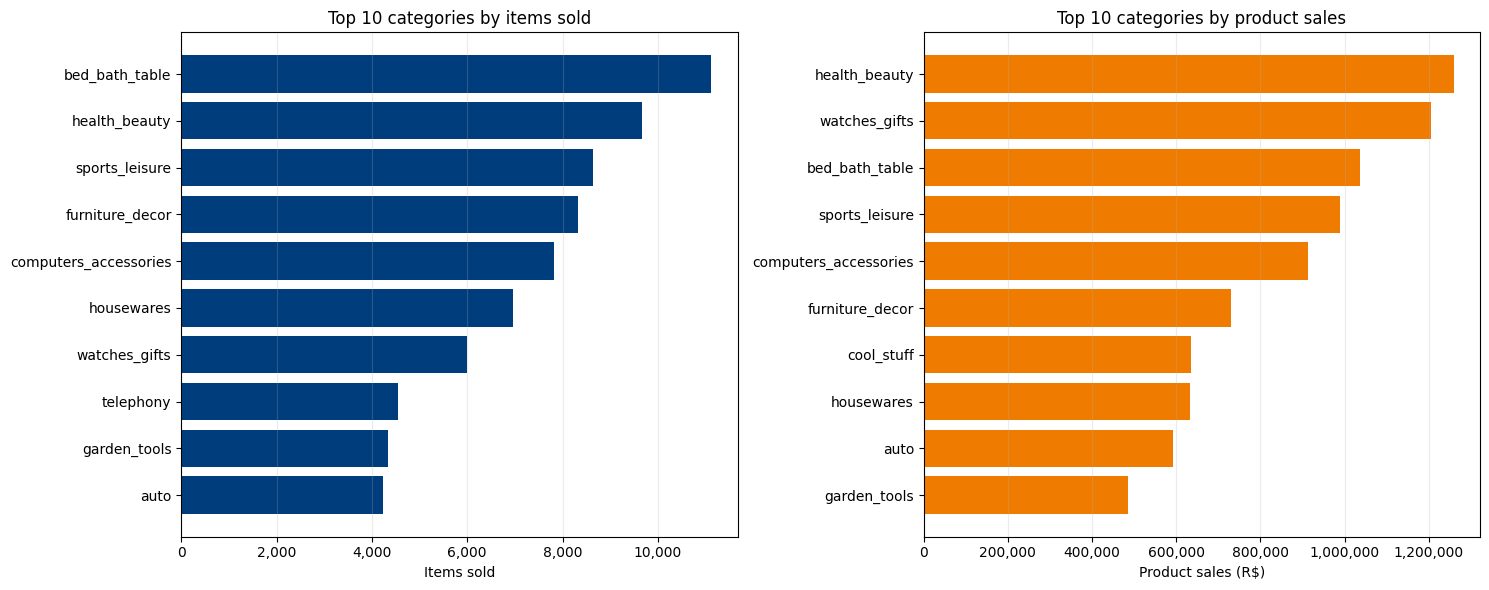

In [315]:
top_categories_by_items = product_category_summary.nlargest(10, "items_sold").sort_values("items_sold")
top_categories_by_sales = product_category_summary.nlargest(10, "product_sales").sort_values("product_sales")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(top_categories_by_items["product_category_name_english"], top_categories_by_items["items_sold"], color="#003D7C")
axes[0].set_title("Top 10 categories by items sold")
axes[0].set_xlabel("Items sold")
axes[0].xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[1].barh(top_categories_by_sales["product_category_name_english"], top_categories_by_sales["product_sales"], color="#EF7C00")
axes[1].set_title("Top 10 categories by product sales")
axes[1].set_xlabel("Product sales (R$)")
axes[1].xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
for axis in axes:
    axis.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### 6.3 Seller Activity and Concentration

In [316]:
seller_summary = (
    line_items.groupby("seller_id", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        items_sold=("order_item_id", "size"),
        product_sales=("price", "sum"),
    )
    .sort_values("product_sales", ascending=False)
)
top_decile_count = int(np.ceil(len(seller_summary) * 0.10))
top_decile_sellers = seller_summary.head(top_decile_count)
seller_concentration = pd.DataFrame({
    "Measure": [
        "Median orders per seller",
        "Top 10% seller share of product sales (%)",
        "Orders involving a top 10% seller (%)",
    ],
    "Value": [
        seller_summary["total_orders"].median(),
        top_decile_sellers["product_sales"].sum() / seller_summary["product_sales"].sum() * 100,
        line_items.loc[line_items["seller_id"].isin(top_decile_sellers["seller_id"]), "order_id"].nunique() / order_count * 100,
    ],
})
seller_concentration

,Measure,Value
0,Median orders per seller,6.00
1,Top 10% seller share of product sales (%),67.56
2,Orders involving a top 10% seller (%),61.22


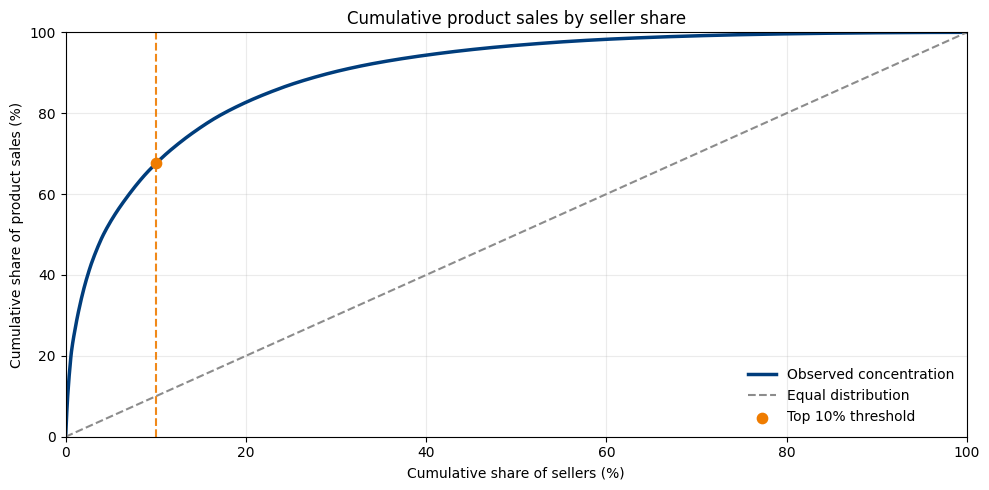

In [317]:
seller_pareto = seller_summary.reset_index(drop=True).copy()
seller_pareto["seller_rank"] = np.arange(1, len(seller_pareto) + 1)
seller_pareto["seller_share_pct"] = seller_pareto["seller_rank"] / len(seller_pareto) * 100
seller_pareto["cumulative_sales_share_pct"] = seller_pareto["product_sales"].cumsum() / seller_pareto["product_sales"].sum() * 100
top_decile_x = top_decile_count / len(seller_pareto) * 100
top_decile_y = seller_pareto.loc[top_decile_count - 1, "cumulative_sales_share_pct"]

fig, axis = plt.subplots(figsize=(10, 5))
axis.plot(
    np.r_[0, seller_pareto["seller_share_pct"]],
    np.r_[0, seller_pareto["cumulative_sales_share_pct"]],
    color="#003D7C", linewidth=2.5, label="Observed concentration",
)
axis.plot([0, 100], [0, 100], color="#8C8C8C", linestyle="--", label="Equal distribution")
axis.axvline(top_decile_x, color="#EF7C00", linestyle="--", alpha=0.9)
axis.scatter(top_decile_x, top_decile_y, color="#EF7C00", s=55, zorder=3, label="Top 10% threshold")
axis.set_title("Cumulative product sales by seller share")
axis.set_xlabel("Cumulative share of sellers (%)")
axis.set_ylabel("Cumulative share of product sales (%)")
axis.set_xlim(0, 100)
axis.set_ylim(0, 100)
axis.grid(alpha=0.25)
axis.legend(frameon=False)
plt.tight_layout()
plt.show()

## 7. Customer Experience and Retention

Review metrics use the consolidated order population across its full date range, with the latest review retained when an order has multiple review records. The repeat-customer rate also uses the full period. For the monthly trend, a returning customer is an active customer whose first purchase occurred before the current month; the January 2017–August 2018 window from Section 5 is used.

In [318]:
review_records = raw["reviews"].copy()
review_records["review_creation_date"] = pd.to_datetime(review_records["review_creation_date"])
core_order_ids = line_items[["order_id"]].drop_duplicates()
latest_reviews = (
    review_records.sort_values(["order_id", "review_creation_date", "review_id"])
    .drop_duplicates("order_id", keep="last")
    [["order_id", "review_score"]]
    .merge(core_order_ids, on="order_id", how="inner", validate="one_to_one")
)
review_score_summary = (
    latest_reviews.groupby("review_score", as_index=False)
    .agg(total_reviews=("order_id", "size"))
    .sort_values("review_score")
)
review_score_summary["review_share_pct"] = review_score_summary["total_reviews"] / len(latest_reviews) * 100
low_rating_rate = latest_reviews["review_score"].le(2).mean() * 100
five_star_rate = latest_reviews["review_score"].eq(5).mean() * 100

customer_history = (
    line_items[["order_id", "customer_id", "order_purchase_timestamp"]]
    .drop_duplicates("order_id")
    .merge(customers[["customer_id", "customer_unique_id"]], on="customer_id", how="left", validate="one_to_one")
    .sort_values(["customer_unique_id", "order_purchase_timestamp", "order_id"])
)
repeat_customer_rate = customer_history.groupby("customer_unique_id")["order_id"].nunique().gt(1).mean() * 100
customer_history["order_month"] = customer_history["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
customer_history["first_purchase_month"] = customer_history.groupby("customer_unique_id")["order_month"].transform("min")
customer_month_activity = customer_history.drop_duplicates(["customer_unique_id", "order_month"]).copy()
customer_month_activity["returning_customer"] = customer_month_activity["order_month"].gt(customer_month_activity["first_purchase_month"])

customer_experience_kpis = pd.DataFrame({
    "Metric": ["Average review score", "Low-rating rate (%)", "Five-star rate (%)", "Five-star minus low-rating rate", "Repeat-customer rate (%)"],
    "Value": [latest_reviews["review_score"].mean(), low_rating_rate, five_star_rate, five_star_rate - low_rating_rate, repeat_customer_rate],
})
customer_experience_kpis

,Metric,Value
0,Average review score,4.10
1,Low-rating rate (%),14.19
2,Five-star rate (%),58.14
3,Five-star minus low-rating rate,43.95
4,Repeat-customer rate (%),3.05


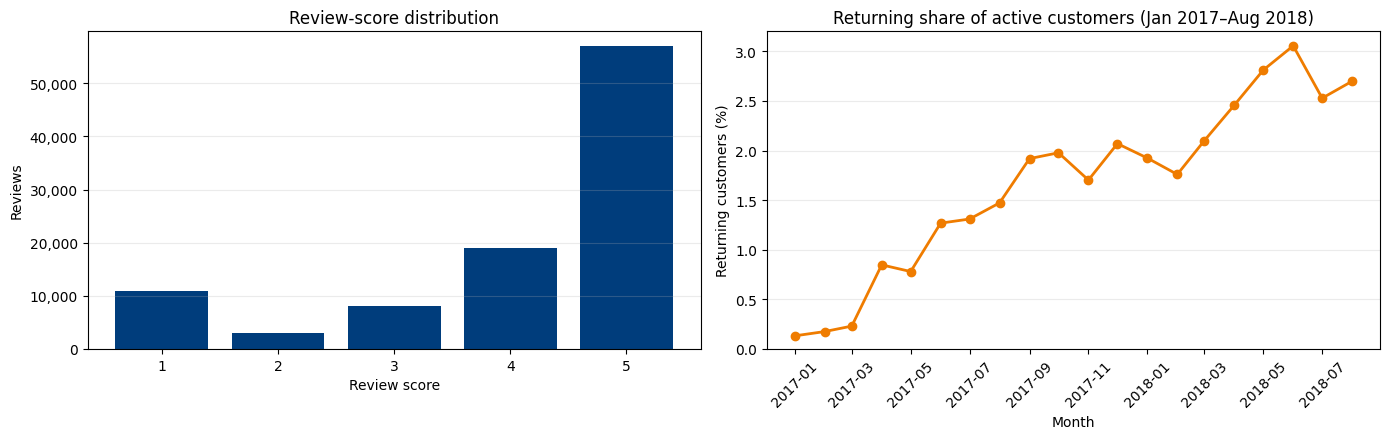

In [319]:
retention_series = (
    customer_month_activity.loc[
        customer_month_activity["order_month"].ge(TREND_START)
        & customer_month_activity["order_month"].lt(TREND_END)
    ]
    .groupby(["order_month", "returning_customer"])["customer_unique_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=[False, True], fill_value=0)
    .rename(columns={False: "new_customers", True: "returning_customers"})
    .reset_index()
)
retention_series["returning_customer_share_pct"] = (
    retention_series["returning_customers"]
    / (retention_series["new_customers"] + retention_series["returning_customers"])
    * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(review_score_summary["review_score"], review_score_summary["total_reviews"], color="#003D7C")
axes[0].set_title("Review-score distribution")
axes[0].set_xlabel("Review score")
axes[0].set_ylabel("Reviews")
axes[0].set_xticks(range(1, 6))
axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[1].plot(retention_series["order_month"], retention_series["returning_customer_share_pct"], marker="o", linewidth=2, color="#EF7C00")
axes[1].set_title("Returning share of active customers (Jan 2017–Aug 2018)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Returning customers (%)")
axes[1].set_ylim(bottom=0)
axes[1].tick_params(axis="x", rotation=45)
for axis in axes:
    axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Payment Method and Instalment Analysis

Payments are analysed at their native payment-record grain. An order may use more than one payment record or method, so payment records are aggregated before reporting method-level values. Instalment charts focus on 1–10 instalments, which account for more than 99% of payment records; the two invalid zero-instalment records and sparse counts above 10 remain covered by the data-quality checks and full summary.

In [320]:
payments = raw["payments"]
payment_method_summary = (
    payments.groupby("payment_type", as_index=False)
    .agg(
        payment_records=("order_id", "size"),
        orders_using_method=("order_id", "nunique"),
        total_payment_value=("payment_value", "sum"),
    )
    .sort_values("total_payment_value", ascending=False)
)
payment_method_summary["payment_record_share_pct"] = payment_method_summary["payment_records"] / len(payments) * 100
payment_method_summary["order_usage_share_pct"] = payment_method_summary["orders_using_method"] / payments["order_id"].nunique() * 100
payment_method_summary["payment_value_share_pct"] = payment_method_summary["total_payment_value"] / payments["payment_value"].sum() * 100
payment_method_summary

,payment_type,payment_records,orders_using_method,total_payment_value,payment_record_share_pct,order_usage_share_pct,payment_value_share_pct
1,credit_card,76795,76505,12542084.19,73.92,76.94,78.34
0,boleto,19784,19784,2869361.27,19.04,19.90,17.92
4,voucher,5775,3866,379436.87,5.56,3.89,2.37
2,debit_card,1529,1528,217989.79,1.47,1.54,1.36
3,not_defined,3,3,0.00,0.00,0.00,0.00


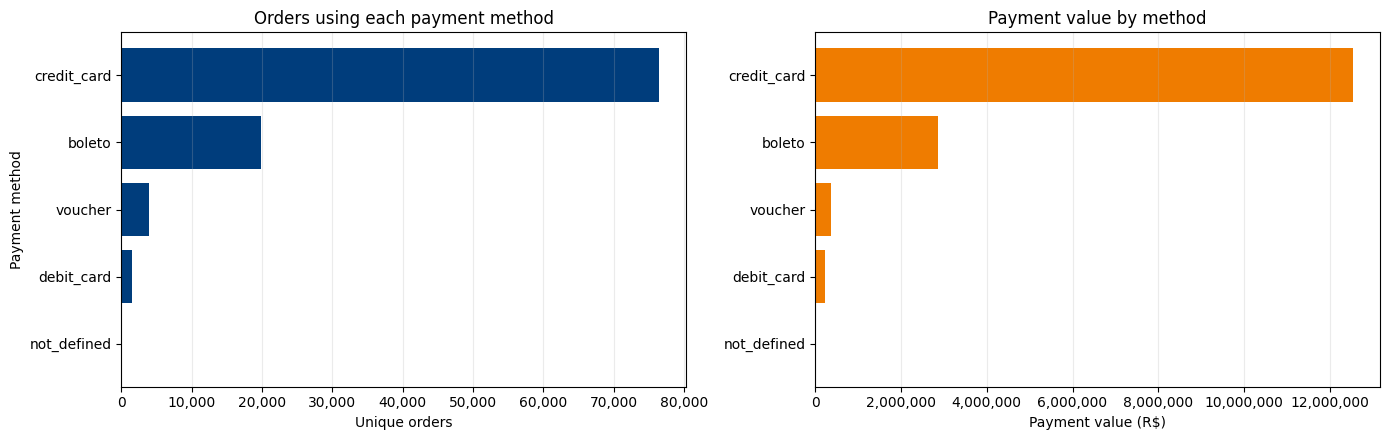

In [321]:
payment_method_plot = payment_method_summary.sort_values("total_payment_value")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].barh(payment_method_plot["payment_type"], payment_method_plot["orders_using_method"], color="#003D7C")
axes[0].set_title("Orders using each payment method")
axes[0].set_xlabel("Unique orders")
axes[0].set_ylabel("Payment method")
axes[0].xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[1].barh(payment_method_plot["payment_type"], payment_method_plot["total_payment_value"], color="#EF7C00")
axes[1].set_title("Payment value by method")
axes[1].set_xlabel("Payment value (R$)")
axes[1].xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
for axis in axes:
    axis.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

,payment_installments,payment_records,median_payment_value
0,0,2,94.31
1,1,52546,73.34
2,2,12413,109.42
3,3,10461,110.42
4,4,7098,117.18
5,5,5239,125.97
6,6,3920,138.55
7,7,1626,140.07
8,8,4268,212.69
9,9,644,99.92


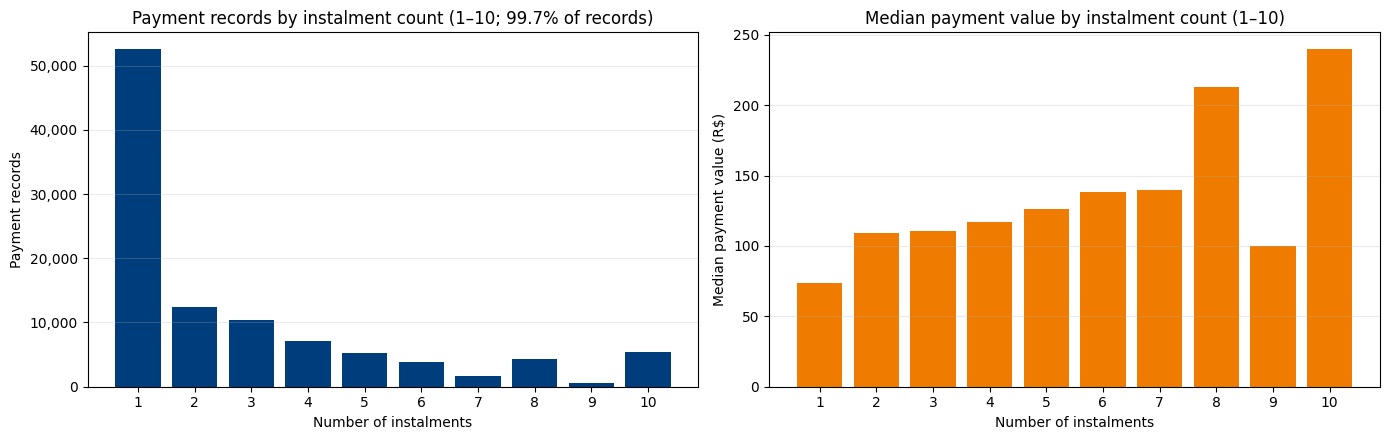

In [322]:
instalment_summary = (
    payments.groupby("payment_installments", as_index=False)
    .agg(
        payment_records=("order_id", "size"),
        median_payment_value=("payment_value", "median"),
    )
    .sort_values("payment_installments")
)
display(instalment_summary)
instalment_plot = instalment_summary.loc[instalment_summary["payment_installments"].between(1, 10)].copy()
common_instalment_share = instalment_plot["payment_records"].sum() / len(payments) * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(instalment_plot["payment_installments"], instalment_plot["payment_records"], color="#003D7C")
axes[0].set_title(f"Payment records by instalment count (1–10; {common_instalment_share:.1f}% of records)")
axes[0].set_xlabel("Number of instalments")
axes[0].set_ylabel("Payment records")
axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[1].bar(instalment_plot["payment_installments"], instalment_plot["median_payment_value"], color="#EF7C00")
axes[1].set_title("Median payment value by instalment count (1–10)")
axes[1].set_xlabel("Number of instalments")
axes[1].set_ylabel("Median payment value (R$)")
axes[1].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
for axis in axes:
    axis.set_xticks(range(1, 11))
    axis.set_ylim(bottom=0)
    axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Correlation and Relationship Exploration

This section examines general relationships among commercial, product, fulfilment, and customer-experience measures. Spearman correlation is used because these variables are skewed and their relationships may not be linear. Correlation indicates association, not causation.

### 9.1 Item-Level Relationships

Spearman correlations use all items with complete values. To keep individual points legible, the scatterplots use a reproducible random sample of up to 10,000 items with strictly positive values and logarithmic axes.

In [323]:
item_relationships = line_items[["price", "freight_value", "product_weight_g"]].dropna()
item_correlations = item_relationships.corr(method="spearman").rename(
    index={"price": "Item price", "freight_value": "Freight value", "product_weight_g": "Product weight"},
    columns={"price": "Item price", "freight_value": "Freight value", "product_weight_g": "Product weight"},
)

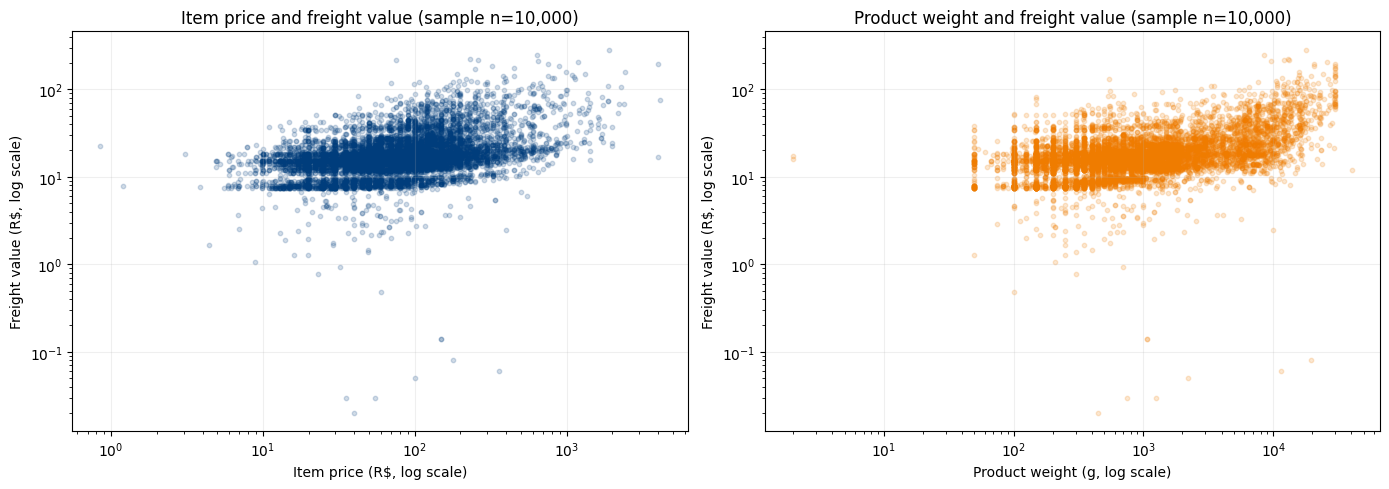

In [324]:
# A reproducible sample reduces overplotting; correlations above use all complete records.
positive_items = item_relationships.loc[
    item_relationships["price"].gt(0)
    & item_relationships["freight_value"].gt(0)
    & item_relationships["product_weight_g"].gt(0)
]
item_plot_sample = positive_items.sample(min(10_000, len(positive_items)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(item_plot_sample["price"], item_plot_sample["freight_value"], s=10, alpha=0.18, color="#003D7C")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title(f"Item price and freight value (sample n={len(item_plot_sample):,})")
axes[0].set_xlabel("Item price (R$, log scale)")
axes[0].set_ylabel("Freight value (R$, log scale)")
axes[1].scatter(item_plot_sample["product_weight_g"], item_plot_sample["freight_value"], s=10, alpha=0.18, color="#EF7C00")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title(f"Product weight and freight value (sample n={len(item_plot_sample):,})")
axes[1].set_xlabel("Product weight (g, log scale)")
axes[1].set_ylabel("Freight value (R$, log scale)")
for axis in axes:
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 9.2 Order-Level and Customer-Experience Relationships

In [325]:
order_relationships = (
    line_items.groupby("order_id", as_index=False)
    .agg(
        item_count=("order_item_id", "size"),
        order_value=("price", "sum"),
        total_freight=("freight_value", "sum"),
        delivery_days=("delivery_days", "first"),
    )
    .merge(latest_reviews, on="order_id", how="left", validate="one_to_one")
)
order_correlations = (
    order_relationships[["item_count", "order_value", "total_freight", "delivery_days", "review_score"]]
    .corr(method="spearman")
    .rename(
        index={"item_count": "Items", "order_value": "Product value", "total_freight": "Freight", "delivery_days": "Delivery days", "review_score": "Review score"},
        columns={"item_count": "Items", "order_value": "Product value", "total_freight": "Freight", "delivery_days": "Delivery days", "review_score": "Review score"},
    )
)

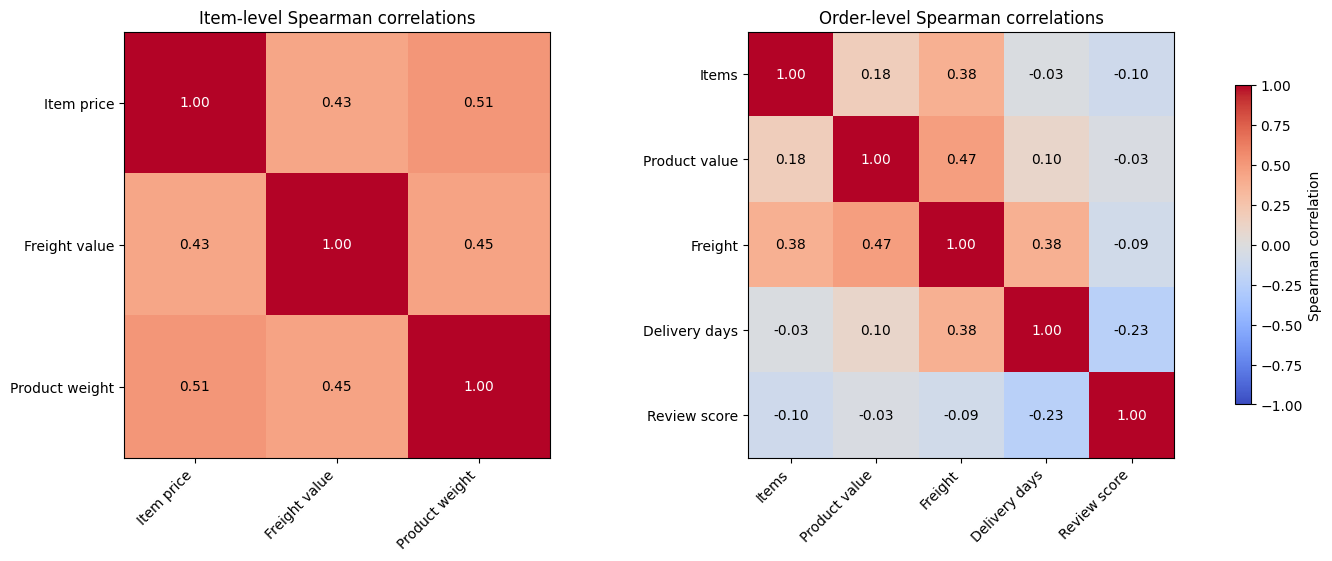

In [326]:
def draw_correlation_matrix(axis, correlations, title):
    image = axis.imshow(correlations, cmap="coolwarm", vmin=-1, vmax=1)
    axis.set_xticks(range(len(correlations.columns)), correlations.columns, rotation=45, ha="right")
    axis.set_yticks(range(len(correlations.index)), correlations.index)
    axis.set_title(title)
    for row in range(len(correlations.index)):
        for column in range(len(correlations.columns)):
            value = correlations.iloc[row, column]
            axis.text(column, row, f"{value:.2f}", ha="center", va="center", color="white" if abs(value) > 0.55 else "black")
    return image

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), layout="constrained")
item_image = draw_correlation_matrix(axes[0], item_correlations, "Item-level Spearman correlations")
order_image = draw_correlation_matrix(axes[1], order_correlations, "Order-level Spearman correlations")
fig.colorbar(order_image, ax=axes, shrink=0.75, label="Spearman correlation")
plt.show()

### 9.3 Group Comparisons

Boxplots compare distributions rather than implying causation. Outlier markers are hidden to keep the central distributions readable, but all observations are retained when calculating the medians, quartiles, and whiskers. Group sample sizes are shown on the x-axis.

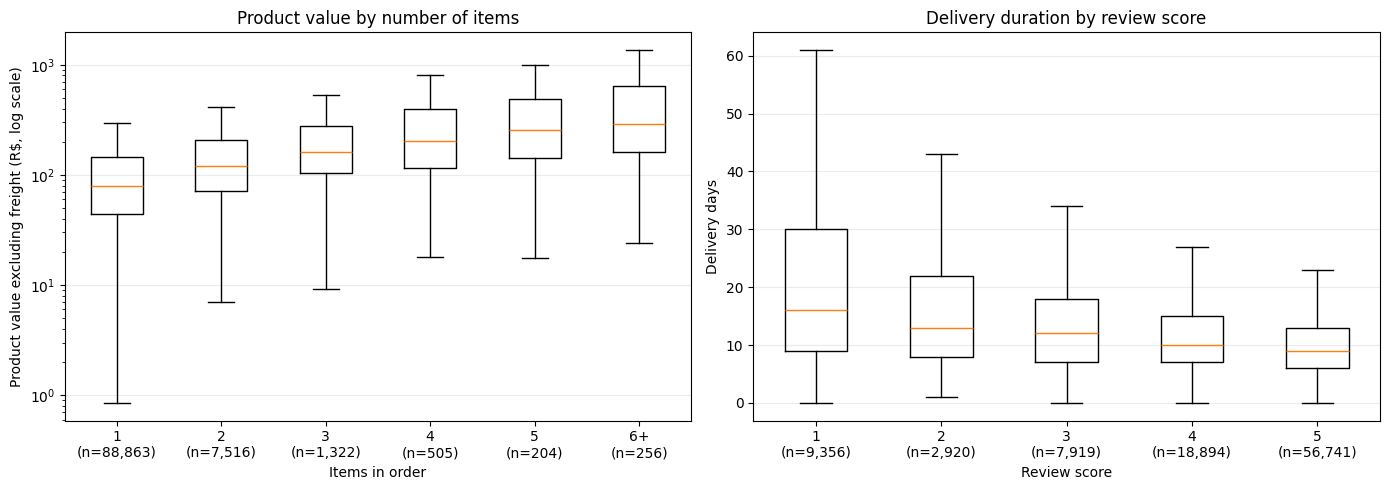

In [327]:
order_plot_data = order_relationships.dropna(subset=["order_value"]).copy()
order_plot_data["item_count_band"] = pd.cut(
    order_plot_data["item_count"],
    bins=[0, 1, 2, 3, 4, 5, np.inf],
    labels=["1", "2", "3", "4", "5", "6+"],
)
basket_labels = list(order_plot_data["item_count_band"].cat.categories)
basket_groups = [
    order_plot_data.loc[order_plot_data["item_count_band"].eq(label), "order_value"]
    for label in basket_labels
]
basket_tick_labels = [f"{label}\n(n={len(values):,})" for label, values in zip(basket_labels, basket_groups)]
reviewed_deliveries = order_relationships.dropna(subset=["delivery_days", "review_score"])
delivery_groups = [
    reviewed_deliveries.loc[reviewed_deliveries["review_score"].eq(score), "delivery_days"]
    for score in range(1, 6)
]
delivery_tick_labels = [f"{score}\n(n={len(values):,})" for score, values in zip(range(1, 6), delivery_groups)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(basket_groups, tick_labels=basket_tick_labels, showfliers=False)
axes[0].set_yscale("log")
axes[0].set_title("Product value by number of items")
axes[0].set_xlabel("Items in order")
axes[0].set_ylabel("Product value excluding freight (R$, log scale)")
axes[1].boxplot(delivery_groups, tick_labels=delivery_tick_labels, showfliers=False)
axes[1].set_title("Delivery duration by review score")
axes[1].set_xlabel("Review score")
axes[1].set_ylabel("Delivery days")
for axis in axes:
    axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()